In [1]:
import os
import ast
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from tqdm import tqdm

In [2]:
DATA_DIR = "/kaggle/input/competitions/global-wheat-detection"
TRAIN_DIR = f"{DATA_DIR}/train"
TEST_DIR = f"{DATA_DIR}/test"

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_EPOCHS = 3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")

train_df["bbox"] = train_df["bbox"].apply(ast.literal_eval)

train_df[["x", "y", "w", "h"]] = pd.DataFrame(
    train_df["bbox"].tolist(),
    index=train_df.index
)

train_df["x2"] = train_df["x"] + train_df["w"]
train_df["y2"] = train_df["y"] + train_df["h"]

image_ids = train_df["image_id"].unique().tolist()

random.shuffle(image_ids)

valid_size = int(len(image_ids) * 0.1)

valid_ids = image_ids[:valid_size]
train_ids = image_ids[valid_size:]

In [4]:
class WheatDataset(Dataset):
    def __init__(self, image_ids, df, image_dir, img_size=512, train=True):
        self.image_ids = image_ids
        self.df = df
        self.image_dir = image_dir
        self.img_size = img_size
        self.train = train

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.image_dir, image_id + ".jpg")

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h0, w0 = image.shape[:2]

        records = self.df[self.df["image_id"] == image_id]
        boxes = records[["x", "y", "x2", "y2"]].values.astype(np.float32)

        scale_x = self.img_size / w0
        scale_y = self.img_size / h0

        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y

        image = cv2.resize(image, (self.img_size, self.img_size))

        if self.train and random.random() < 0.5:
            image = image[:, ::-1, :].copy()
            boxes[:, [0, 2]] = self.img_size - boxes[:, [2, 0]]

        image = image.astype(np.float32) / 255.0
        image = torch.tensor(image).permute(2, 0, 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target

In [5]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [6]:
train_dataset = WheatDataset(
    train_ids,
    train_df,
    TRAIN_DIR,
    img_size=IMG_SIZE,
    train=True
)

valid_dataset = WheatDataset(
    valid_ids,
    train_df,
    TRAIN_DIR,
    img_size=IMG_SIZE,
    train=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

In [7]:
def get_model():
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights="DEFAULT",
        min_size=IMG_SIZE,
        max_size=IMG_SIZE
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes=2
    )

    return model

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = get_model()
model.to(device)

cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 198MB/s]  


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(512,), max_size=512, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(i

In [9]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5
)

scaler = torch.amp.GradScaler("cuda")

In [10]:
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    scheduler.step()

    print(f"Epoch {epoch+1} Loss: {total_loss / len(train_loader):.4f}")

Epoch 1/3: 100%|██████████| 759/759 [02:53<00:00,  4.37it/s, loss=0.898]


Epoch 1 Loss: 0.9489


Epoch 2/3: 100%|██████████| 759/759 [02:56<00:00,  4.29it/s, loss=0.665]


Epoch 2 Loss: 0.8174


Epoch 3/3: 100%|██████████| 759/759 [02:57<00:00,  4.27it/s, loss=0.818]

Epoch 3 Loss: 0.7653


In [11]:
torch.save(model.state_dict(), "fasterrcnn_wheat_best.pth")

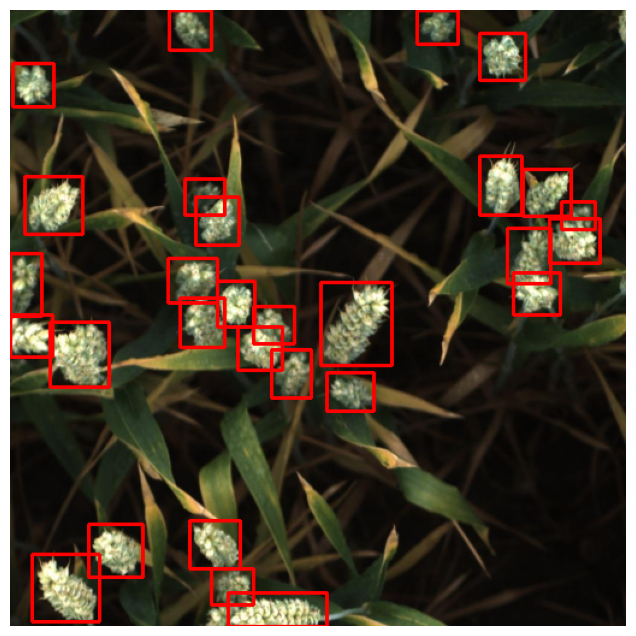

In [12]:
model.eval()

images, targets = next(iter(valid_loader))

with torch.no_grad():
    outputs = model([img.to(device) for img in images])

img = images[0].permute(1, 2, 0).cpu().numpy().copy()

boxes = outputs[0]["boxes"].detach().cpu().numpy()
scores = outputs[0]["scores"].detach().cpu().numpy()

for box, score in zip(boxes, scores):
    if score < 0.5:
        continue

    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(img, (x1, y1), (x2, y2), (1, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
class WheatTestDataset(Dataset):
    def __init__(self, image_dir, img_size=512):
        self.image_dir = image_dir
        self.img_size = img_size
        self.image_files = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        file_name = self.image_files[idx]
        image_id = file_name.replace(".jpg", "")

        image_path = os.path.join(self.image_dir, file_name)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h0, w0 = image.shape[:2]

        image = cv2.resize(image, (self.img_size, self.img_size))
        image = image.astype(np.float32) / 255.0
        image = torch.tensor(image).permute(2, 0, 1)

        return image, image_id, w0, h0

In [14]:
test_dataset = WheatTestDataset(TEST_DIR, img_size=IMG_SIZE)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

In [15]:
results = []

model.eval()

for images, image_ids, orig_w, orig_h in tqdm(test_loader):
    images = [img.to(device) for img in images]

    with torch.no_grad():
        outputs = model(images)

    boxes = outputs[0]["boxes"].detach().cpu().numpy()
    scores = outputs[0]["scores"].detach().cpu().numpy()

    orig_w = orig_w.item()
    orig_h = orig_h.item()

    scale_x = orig_w / IMG_SIZE
    scale_y = orig_h / IMG_SIZE

    pred_strings = []

    for box, score in zip(boxes, scores):
        if score < 0.45:
            continue

        x1, y1, x2, y2 = box

        x1 *= scale_x
        x2 *= scale_x
        y1 *= scale_y
        y2 *= scale_y

        w = x2 - x1
        h = y2 - y1

        pred_strings.append(
            f"{score:.4f} {x1:.0f} {y1:.0f} {w:.0f} {h:.0f}"
        )

    results.append({
        "image_id": image_ids[0],
        "PredictionString": " ".join(pred_strings)
    })

100%|██████████| 10/10 [00:00<00:00, 14.13it/s]


In [16]:
submission = pd.DataFrame(results)

submission.to_csv("submission.csv", index=False)

display(submission)

,image_id,PredictionString
0,2fd875eaa,0.9974 108 584 142 80 0.9945 464 349 125 97 0....
1,348a992bb,0.9925 736 225 137 81 0.9895 4 315 112 94 0.98...
2,51b3e36ab,0.9901 537 30 259 133 0.9898 237 641 95 158 0....
3,51f1be19e,0.9709 289 474 122 113 0.9523 807 769 105 84 0...
4,53f253011,0.9835 147 95 86 92 0.9816 24 36 131 104 0.981...
5,796707dd7,0.9632 713 831 101 87 0.9620 903 334 100 83 0....
6,aac893a91,0.9834 76 2 99 159 0.9811 620 920 73 98 0.9707...
7,cb8d261a3,0.9854 269 773 101 70 0.9850 33 561 168 93 0.9...
8,cc3532ff6,0.9902 775 831 158 155 0.9895 374 2 84 96 0.98...
9,f5a1f0358,0.9831 695 206 105 84 0.9756 884 641 90 146 0....


In [17]:
!ls

fasterrcnn_wheat_best.pth  submission.csv
